# KPMG arXiv Exploratory Data Analysis

The default run analyzes the committed 100-paper metadata snapshot and the fixed
25-paper PDF manifest. It reads cached PDFs without downloading or deleting them.
Metadata tables, charts, and summaries must all describe that same snapshot.

Optional collection is controlled by `REFRESH_METADATA` and
`DOWNLOAD_MISSING_PDFS` below. Leave both `False` for reproducible analysis.
Refreshing metadata changes the dataset and requires reviewing the locked sample
and all findings; it is separate from replaying the recorded EDA.


## Environment

Use the repository's Python environment. For notebook charts, also install
`matplotlib` (`python -m pip install matplotlib`). Optional metadata recollection
requires `arxiv` (`python -m pip install arxiv`).

Run the notebook from the repository root or `notebooks/`. Before the PDF-analysis
cells, populate `data/pdfs/` with the locked sample, for example by explicitly
running `python src/data_ingestion.py` from the repository root. That command may
download missing PDFs; the default notebook run does not.


In [1]:
from pathlib import Path
import hashlib
import pandas as pd

REFRESH_METADATA = False
DOWNLOAD_MISSING_PDFS = False

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data/metadata/arxiv_csAI_100_metadata.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
metadata_path = PROJECT_ROOT / "data/metadata/arxiv_csAI_100_metadata.csv"
sample_path = PROJECT_ROOT / "data/metadata/arxiv_csAI_25_pdf_sample.csv"
if not metadata_path.exists() or not sample_path.exists():
    raise FileNotFoundError("Run from the repository root or notebooks/ with the tracked CSV files.")


In [2]:
if REFRESH_METADATA:
    import arxiv
    client = arxiv.Client()
    
    month_ranges = [
        ("20260101", "20260131", 11),
        ("20260201", "20260228", 11),
        ("20260301", "20260331", 11),
        ("20260401", "20260430", 11),
        ("20260501", "20260531", 11),
        ("20260601", "20260630", 11),
        ("20260701", "20260731", 11),
        ("20260801", "20260831", 11),
        ("20260901", "20260930", 12),
    ]
    
    results = []
    
    for start_date, end_date, num_papers in month_ranges:
        search = arxiv.Search(
            query=(
                f"cat:cs.AI AND "
                f"submittedDate:[{start_date}0000 TO {end_date}2359]"
            ),
            max_results=num_papers,
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )
    
        month_results = list(client.results(search))
        results.extend(month_results)
    
        print(
            f"{start_date} to {end_date}: "
            f"{len(month_results)} papers"
        )
    
    print("\nTotal papers:", len(results))
else:
    print("Using committed metadata; live arXiv collection is disabled.")


Using committed metadata; live arXiv collection is disabled.


In [3]:
if REFRESH_METADATA:
    papers = []
    for paper in results:
        papers.append({
            "arxiv_id": paper.entry_id.split("/")[-1],
            "title": paper.title,
            "authors": ", ".join(author.name for author in paper.authors),
            "abstract": paper.summary,
            "categories": ", ".join(paper.categories),
            "published": paper.published,
            "updated": paper.updated,
            "pdf_url": paper.pdf_url,
        })
    df = pd.DataFrame(papers)
else:
    df = pd.read_csv(metadata_path)
for field in ("published", "updated"):
    df[field] = pd.to_datetime(df[field], utc=True)


In [4]:
df.head()


,arxiv_id,title,authors,abstract,categories,published,updated,pdf_url
0,2602.00937v3,CLAMP: Contrastive Learning for 3D Multi-View ...,"I-Chun Arthur Liu, Krzysztof Choromanski, Sand...",Leveraging pre-trained 2D image representation...,"cs.RO, cs.AI, cs.CV, cs.LG",2026-01-31 23:32:54+00:00,2026-05-06 16:54:58+00:00,https://arxiv.org/pdf/2602.00937v3
1,2602.00933v3,MCP-Atlas: A Large-Scale Benchmark for Tool-Us...,"Chaithanya Bandi, Razvan-Gabriel Dumitru, Ben ...",The Model Context Protocol (MCP) is emerging a...,"cs.SE, cs.AI",2026-01-31 23:19:39+00:00,2026-05-19 23:26:22+00:00,https://arxiv.org/pdf/2602.00933v3
2,2602.00931v2,Continuous-Utility Direct Preference Optimization,"Muhammad Ahmed Mohsin, Muhammad Umer, Ahsan Bi...",Large language model reasoning is often treate...,"cs.LG, cs.AI",2026-01-31 23:15:32+00:00,2026-04-23 07:38:14+00:00,https://arxiv.org/pdf/2602.00931v2
3,2602.00929v1,Learning Abstractions for Hierarchical Plannin...,"Zergham Ahmed, Kazuki Irie, Joshua B. Tenenbau...",Humans learn abstractions and use them to plan...,cs.AI,2026-01-31 23:01:51+00:00,2026-01-31 23:01:51+00:00,https://arxiv.org/pdf/2602.00929v1
4,2602.00924v3,Supervised sparse auto-encoders for interpreta...,"Ouns El Harzli, Hugo Wallner, Yoonsoo Nam, Hai...",Sparse auto-encoders (SAEs) have re-emerged as...,cs.AI,2026-01-31 22:47:54+00:00,2026-05-17 22:16:52+00:00,https://arxiv.org/pdf/2602.00924v3


In [5]:
df.shape

(100, 8)

In [6]:
if REFRESH_METADATA:
    df.to_csv(metadata_path, index=False)
    print("Refreshed metadata saved; review the locked sample and all EDA findings.")
else:
    print("Committed metadata preserved; no CSV writes.")
print("Metadata SHA-256:", hashlib.sha256(metadata_path.read_bytes()).hexdigest())


Committed metadata preserved; no CSV writes.
Metadata SHA-256: 3530e739bb76f4d72813771e5dc2dc18e9eeffe3e3e46ff22d67aad16b2c008a


## Fixed PDF sample

Read the locked manifest and reuse cached PDFs for length and text-extractability analysis.


In [7]:
pdf_dir = PROJECT_ROOT / "data/pdfs"
print("PDF cache: data/pdfs/ (existing PDFs are preserved)")


PDF cache: data/pdfs/ (existing PDFs are preserved)


In [8]:
pdf_manifest = pd.read_csv(sample_path)
missing_ids = sorted(set(pdf_manifest["arxiv_id"]) - set(df["arxiv_id"]))
if missing_ids:
    raise ValueError(f"Locked sample IDs missing from metadata: {missing_ids}")
print("Fixed PDF sample:", len(pdf_manifest))
pdf_manifest.head()


Fixed PDF sample: 25


,arxiv_id,title,published,pdf_url
0,2602.00937v3,CLAMP: Contrastive Learning for 3D Multi-View ...,2026-01-31 23:32:54+00:00,https://arxiv.org/pdf/2602.00937v3
1,2602.00933v3,MCP-Atlas: A Large-Scale Benchmark for Tool-Us...,2026-01-31 23:19:39+00:00,https://arxiv.org/pdf/2602.00933v3
2,2602.00931v2,Continuous-Utility Direct Preference Optimization,2026-01-31 23:15:32+00:00,https://arxiv.org/pdf/2602.00931v2
3,2603.00829v2,Constitutional Black-Box Monitoring for Schemi...,2026-02-28 22:31:32+00:00,https://arxiv.org/pdf/2603.00829v2
4,2603.00824v2,A Gauge Theory of Superposition: Toward a Shea...,2026-02-28 22:05:14+00:00,https://arxiv.org/pdf/2603.00824v2


In [9]:
if DOWNLOAD_MISSING_PDFS:
    import urllib.request
    pdf_dir.mkdir(parents=True, exist_ok=True)
    for _, row in pdf_manifest.iterrows():
        file_path = pdf_dir / (row["arxiv_id"] + ".pdf")
        if not file_path.exists():
            urllib.request.urlretrieve(row["pdf_url"], file_path)
else:
    print("PDF downloads disabled; using existing cached files.")


PDF downloads disabled; using existing cached files.


In [10]:
pdf_files = (pdf_manifest["arxiv_id"] + ".pdf").tolist()
missing_pdfs = [name for name in pdf_files if not (pdf_dir / name).exists()]
if missing_pdfs:
    raise FileNotFoundError(
        "Populate the locked PDF cache before running the PDF-analysis cells: "
        + ", ".join(missing_pdfs)
    )
print("PDFs selected for analysis:", len(pdf_files))


PDFs selected for analysis: 25


## Task 2.2 - Explore Metadata
Inspect the metadata fields, data types, and example values.

In [11]:
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   arxiv_id    100 non-null    str                
 1   title       100 non-null    str                
 2   authors     100 non-null    str                
 3   abstract    100 non-null    str                
 4   categories  100 non-null    str                
 5   published   100 non-null    datetime64[us, UTC]
 6   updated     100 non-null    datetime64[us, UTC]
 7   pdf_url     100 non-null    str                
dtypes: datetime64[us, UTC](2), str(6)
memory usage: 6.4 KB


,arxiv_id,title,authors,abstract,categories,published,updated,pdf_url
0,2602.00937v3,CLAMP: Contrastive Learning for 3D Multi-View ...,"I-Chun Arthur Liu, Krzysztof Choromanski, Sand...",Leveraging pre-trained 2D image representation...,"cs.RO, cs.AI, cs.CV, cs.LG",2026-01-31 23:32:54+00:00,2026-05-06 16:54:58+00:00,https://arxiv.org/pdf/2602.00937v3
1,2602.00933v3,MCP-Atlas: A Large-Scale Benchmark for Tool-Us...,"Chaithanya Bandi, Razvan-Gabriel Dumitru, Ben ...",The Model Context Protocol (MCP) is emerging a...,"cs.SE, cs.AI",2026-01-31 23:19:39+00:00,2026-05-19 23:26:22+00:00,https://arxiv.org/pdf/2602.00933v3
2,2602.00931v2,Continuous-Utility Direct Preference Optimization,"Muhammad Ahmed Mohsin, Muhammad Umer, Ahsan Bi...",Large language model reasoning is often treate...,"cs.LG, cs.AI",2026-01-31 23:15:32+00:00,2026-04-23 07:38:14+00:00,https://arxiv.org/pdf/2602.00931v2
3,2602.00929v1,Learning Abstractions for Hierarchical Plannin...,"Zergham Ahmed, Kazuki Irie, Joshua B. Tenenbau...",Humans learn abstractions and use them to plan...,cs.AI,2026-01-31 23:01:51+00:00,2026-01-31 23:01:51+00:00,https://arxiv.org/pdf/2602.00929v1
4,2602.00924v3,Supervised sparse auto-encoders for interpreta...,"Ouns El Harzli, Hugo Wallner, Yoonsoo Nam, Hai...",Sparse auto-encoders (SAEs) have re-emerged as...,cs.AI,2026-01-31 22:47:54+00:00,2026-05-17 22:16:52+00:00,https://arxiv.org/pdf/2602.00924v3


In [12]:
categories = df["categories"].str.split(", ").explode()

print("Number of unique categories:", categories.nunique())
print("Categories:", sorted(categories.unique()))

Number of unique categories: 27
Categories: ['cs.AI', 'cs.CL', 'cs.CR', 'cs.CV', 'cs.CY', 'cs.DC', 'cs.DS', 'cs.HC', 'cs.IR', 'cs.IT', 'cs.LG', 'cs.MA', 'cs.MM', 'cs.NE', 'cs.NI', 'cs.RO', 'cs.SD', 'cs.SE', 'eess.AS', 'eess.IV', 'eess.SP', 'eess.SY', 'math.OC', 'physics.flu-dyn', 'q-bio.GN', 'quant-ph', 'stat.ML']


### Category findings
The sample contains 100 papers spanning 27 unique category labels.
Papers can have multiple categories, stored as comma-separated text.
These labels could help the research agent filter papers by topic.

In [13]:
print("Earliest submission:", df["published"].min())
print("Latest submission:", df["published"].max())

Earliest submission: 2026-01-31 20:24:56+00:00
Latest submission: 2026-09-30 07:56:52+00:00


### Submission-date findings
The 100 sampled papers span January through September 2026.
The sample was intentionally distributed across multiple months to provide broader time coverage for exploratory analysis.

### Metadata Field Summary

The dataset contains 100 papers and 8 metadata fields.

| Field | Stored as | Purpose in the research agent |
|---|---|---|
| arxiv_id | Text | Identifies the paper and its version; links metadata to its PDF |
| title | Text | Shows the paper's name in search results |
| authors | Comma-separated text | Identifies who wrote the paper for attribution |
| abstract | Text | Provides a short description that can help find relevant papers |
| categories | Comma-separated text | Allows filtering papers by research topic |
| published | UTC date and time | Allows filtering papers by submission date |
| updated | UTC date and time | Records when the paper was last updated |
| pdf_url | Text | Provides the link for downloading the paper |

### Findings and Limitations

- All 8 fields have 100 non-null values. The six text fields also contain no empty or whitespace-only values.
- The sample contains 27 unique category labels, and papers can have multiple labels.
- The sample spans January through September 2026, with approximately equal numbers of papers selected from each month.
- Because the sampling strategy intentionally balances the months, the sample should not be interpreted as showing the true monthly publication volume on arXiv.
- Category labels should be separated before filtering or counting individual topics.

In [14]:
text_columns = df.select_dtypes(include=["str", "object"])

blank_counts = text_columns.apply(
    lambda column: column.str.strip().eq("").sum()
)

print(blank_counts)

arxiv_id      0
title         0
authors       0
abstract      0
categories    0
pdf_url       0
dtype: int64


In [15]:
for title in df["title"].head(10):
    print(title)
    print()

CLAMP: Contrastive Learning for 3D Multi-View Action-Conditioned Robotic Manipulation Pretraining

MCP-Atlas: A Large-Scale Benchmark for Tool-Use Competency with Real MCP Servers

Continuous-Utility Direct Preference Optimization

Learning Abstractions for Hierarchical Planning in Program-Synthesis Agents

Supervised sparse auto-encoders for interpretable and compositional representations

A Baseline Multimodal Approach to Emotion Recognition in Conversations

Do Schwartz Higher-Order Values Help Sentence-Level Human Value Detection? A Study of Hierarchical Gating and Calibration

Synapse: Federated Tool Routing via Typed Compendium Artifacts

Hallucination is a Consequence of Space-Optimality: A Rate-Distortion Theorem for Membership Testing

GAPNet: Plug-in Jointly Learning Task-Specific Graph for Dynamic Stock Relation



### Title inspection
The first 10 titles are readable, with no obvious text corruption.
They vary in length and describe different research topics.
Titles can help users identify papers in search results.
This check covers only the first 10 titles.

In [16]:
print("Duplicate arXiv IDs:", df["arxiv_id"].duplicated().sum())

Duplicate arXiv IDs: 0


## Task 2.3 - Analyze Distributions
Analyze the distribution of research categories, publication dates, and paper lengths in the sample.

In [17]:
import matplotlib.pyplot as plt

category_counts = (
    df["categories"]
    .str.split(", ")
    .explode()
    .value_counts()
)

category_counts

categories
cs.AI              100
cs.LG               31
cs.CL               22
cs.CV               12
cs.SE                8
cs.MA                7
cs.RO                5
cs.CY                4
cs.CR                4
cs.SD                3
cs.DC                3
eess.AS              2
cs.IT                2
cs.IR                2
cs.HC                2
cs.NI                2
stat.ML              2
cs.DS                1
cs.NE                1
quant-ph             1
eess.IV              1
cs.MM                1
q-bio.GN             1
eess.SY              1
physics.flu-dyn      1
math.OC              1
eess.SP              1
Name: count, dtype: int64

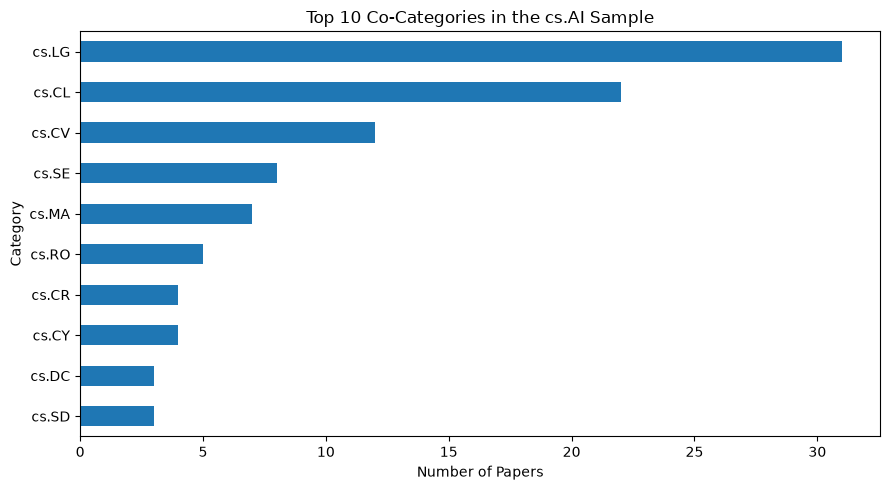

In [18]:
other_categories = category_counts.drop("cs.AI", errors="ignore").head(10)

other_categories.sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Top 10 Co-Categories in the cs.AI Sample")
plt.xlabel("Number of Papers")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Category distribution findings

All 100 papers are classified under cs.AI because the sample was collected from the cs.AI category.

Among the additional categories, cs.LG is the most common with 31 papers, followed by cs.CL with 22 papers and cs.CV with 12 papers. This shows that the sample covers AI research that overlaps with several areas such as machine learning, computational linguistics, computer vision, software engineering, multi-agent systems, and robotics.

Because a paper can have multiple category labels, the category counts can overlap and do not sum to 100.

In [19]:
month_counts = (
    df["published"]
    .dt.strftime("%Y-%m")
    .value_counts()
    .sort_index()
)

month_counts

published
2026-01    11
2026-02    11
2026-03    11
2026-04    11
2026-05    11
2026-06    11
2026-07    11
2026-08    11
2026-09    12
Name: count, dtype: int64

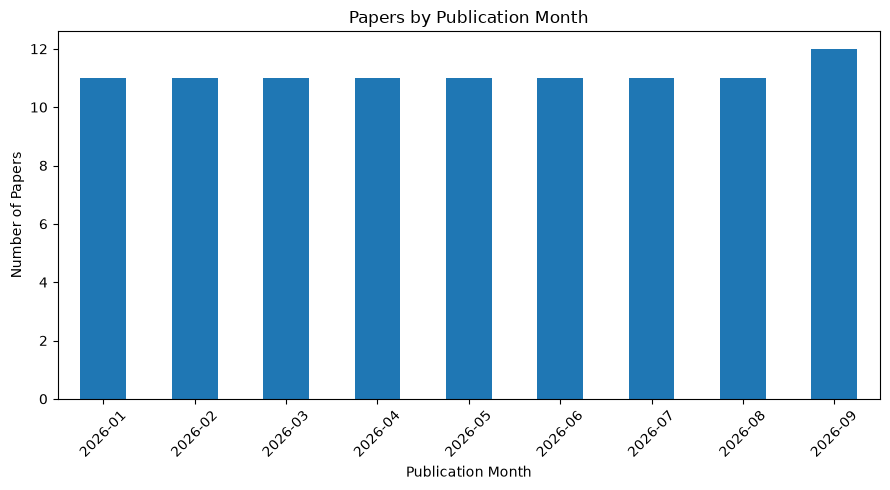

In [20]:
month_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Papers by Publication Month")
plt.xlabel("Publication Month")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The sample is distributed across January through September 2026, with approximately 11 papers from each month and 12 papers from September.

This balanced monthly sampling provides broader time coverage for exploratory analysis. Because the sample was intentionally balanced across months, these counts do not represent the true monthly publication volume on arXiv.

In [21]:
import fitz  # PyMuPDF
import os
paper_lengths = []

for filename in pdf_files:
    pdf_path = os.path.join(pdf_dir, filename)

    with fitz.open(pdf_path) as doc:
        page_count = len(doc)

    paper_lengths.append({
        "filename": filename,
        "pages": page_count
    })

paper_lengths[:5]

[{'filename': '2602.00937v3.pdf', 'pages': 16},
 {'filename': '2602.00933v3.pdf', 'pages': 25},
 {'filename': '2602.00931v2.pdf', 'pages': 32},
 {'filename': '2603.00829v2.pdf', 'pages': 36},
 {'filename': '2603.00824v2.pdf', 'pages': 35}]

In [22]:
len(paper_lengths)

25

In [23]:
length_df = pd.DataFrame(paper_lengths)
length_df

,filename,pages
0,2602.00937v3.pdf,16
1,2602.00933v3.pdf,25
2,2602.00931v2.pdf,32
3,2603.00829v2.pdf,36
4,2603.00824v2.pdf,35
5,2603.00823v2.pdf,18
6,2604.00324v1.pdf,157
7,2604.00319v1.pdf,36
8,2604.00314v1.pdf,7
9,2605.00292v2.pdf,20


In [24]:
print("Average pages:", round(length_df["pages"].mean(), 2))
print("Median pages:", length_df["pages"].median())
print("Shortest paper:", length_df["pages"].min())
print("Longest paper:", length_df["pages"].max())

Average pages: 27.72
Median pages: 23.0
Shortest paper: 7
Longest paper: 157


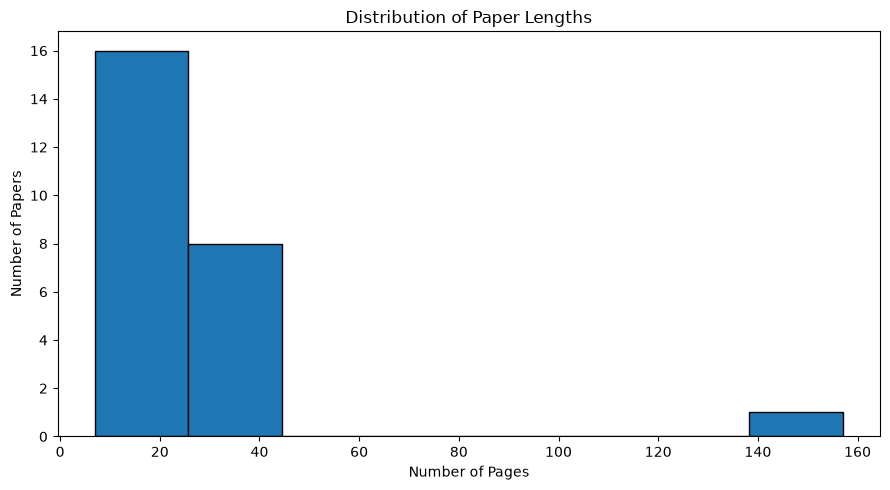

In [25]:
length_df["pages"].plot(
    kind="hist",
    bins=8,
    figsize=(9, 5),
    edgecolor="black"
)

plt.title("Distribution of Paper Lengths")
plt.xlabel("Number of Pages")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

### Paper-length distribution findings

Most of the 25 sampled papers are between about 7 and 40 pages, with many concentrated around the 10-25 page range.

One paper is much longer at 157 pages, creating a clear right-skewed distribution. This outlier increases the average paper length to 27.72 pages, while the median remains lower at 23 pages.

Because of this outlier, the median is a better representation of the typical paper length in this sample.

In [26]:
df["category_count"] = (
    df["categories"]
    .str.split(", ")
    .apply(len)
)

df["author_count"] = (
    df["authors"]
    .str.split(", ")
    .apply(len)
)

df["title_word_count"] = (
    df["title"]
    .str.split()
    .apply(len)
)

df["abstract_word_count"] = (
    df["abstract"]
    .str.split()
    .apply(len)
)

df["revision_number"] = (
    df["arxiv_id"]
    .str.extract(r"v(\d+)$")[0]
    .astype(int)
)

df["days_until_update"] = (
    df["updated"] - df["published"]
).dt.days

df[
    [
        "category_count",
        "author_count",
        "title_word_count",
        "abstract_word_count",
        "revision_number",
        "days_until_update"
    ]
].describe()

,category_count,author_count,title_word_count,abstract_word_count,revision_number,days_until_update
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.0000
mean,2.210000,4.870000,10.120000,191.060000,1.380000,18.8300
std,0.945964,3.653295,3.032751,42.026884,0.850193,41.9078
min,1.000000,1.000000,4.000000,54.000000,1.000000,0.0000
25%,2.000000,3.000000,8.000000,167.000000,1.000000,0.0000
50%,2.000000,4.000000,10.000000,190.500000,1.000000,0.0000
75%,3.000000,6.000000,12.000000,221.000000,1.250000,0.2500
max,5.000000,23.000000,23.000000,297.000000,7.000000,169.0000


In [27]:
df

,arxiv_id,title,authors,abstract,categories,published,updated,pdf_url,category_count,author_count,title_word_count,abstract_word_count,revision_number,days_until_update
0,2602.00937v3,CLAMP: Contrastive Learning for 3D Multi-View ...,"I-Chun Arthur Liu, Krzysztof Choromanski, Sand...",Leveraging pre-trained 2D image representation...,"cs.RO, cs.AI, cs.CV, cs.LG",2026-01-31 23:32:54+00:00,2026-05-06 16:54:58+00:00,https://arxiv.org/pdf/2602.00937v3,4,4,10,222,3,94
1,2602.00933v3,MCP-Atlas: A Large-Scale Benchmark for Tool-Us...,"Chaithanya Bandi, Razvan-Gabriel Dumitru, Ben ...",The Model Context Protocol (MCP) is emerging a...,"cs.SE, cs.AI",2026-01-31 23:19:39+00:00,2026-05-19 23:26:22+00:00,https://arxiv.org/pdf/2602.00933v3,2,23,11,257,3,108
2,2602.00931v2,Continuous-Utility Direct Preference Optimization,"Muhammad Ahmed Mohsin, Muhammad Umer, Ahsan Bi...",Large language model reasoning is often treate...,"cs.LG, cs.AI",2026-01-31 23:15:32+00:00,2026-04-23 07:38:14+00:00,https://arxiv.org/pdf/2602.00931v2,2,9,4,170,2,81
3,2602.00929v1,Learning Abstractions for Hierarchical Plannin...,"Zergham Ahmed, Kazuki Irie, Joshua B. Tenenbau...",Humans learn abstractions and use them to plan...,cs.AI,2026-01-31 23:01:51+00:00,2026-01-31 23:01:51+00:00,https://arxiv.org/pdf/2602.00929v1,1,5,8,176,1,0
4,2602.00924v3,Supervised sparse auto-encoders for interpreta...,"Ouns El Harzli, Hugo Wallner, Yoonsoo Nam, Hai...",Sparse auto-encoders (SAEs) have re-emerged as...,cs.AI,2026-01-31 22:47:54+00:00,2026-05-17 22:16:52+00:00,https://arxiv.org/pdf/2602.00924v3,1,4,8,111,3,105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2609.39148v1,Do Self-Evolving Skills Generalize to Held-Out...,"Xihao Piao, Zifeng Wang, Zhen Chen",AI agents can externalize what they learn from...,cs.AI,2026-09-30 07:14:35+00:00,2026-09-30 07:14:35+00:00,https://arxiv.org/pdf/2609.39148v1,1,3,7,264,1,0
96,2609.39146v1,MADBench: Benchmarking the Security of Multi-A...,"Yuwan Liu, Jiaming Zhang, Yue Huang, Sisi Duan",Multi-agent debate (MAD) can improve large lan...,cs.AI,2026-09-30 07:12:59+00:00,2026-09-30 07:12:59+00:00,https://arxiv.org/pdf/2609.39146v1,1,4,7,223,1,0
97,2609.39145v1,Blackout vs. Freeze: Analyzing Physical Failur...,"Heejae Suh, Jongwook Han, Zahra Gholami, Yohan Jo",Unreliable visual inputs can harm task perform...,"cs.RO, cs.AI",2026-09-30 07:11:58+00:00,2026-09-30 07:11:58+00:00,https://arxiv.org/pdf/2609.39145v1,2,4,12,183,1,0
98,2609.39143v1,RefCon: Iterative Refinement and Contrastive M...,"Ubaidillah Ariq Prathama, Bo Liu, Yeo Boon Hon...",Long-horizon agent interactions generate usefu...,"cs.AI, cs.LG, cs.MA",2026-09-30 07:10:38+00:00,2026-09-30 07:10:38+00:00,https://arxiv.org/pdf/2609.39143v1,3,6,10,145,1,0


In [28]:
revision_counts = (
    df["revision_number"]
    .value_counts()
    .sort_index()
)

revision_counts

revision_number
1    75
2    17
3     6
4     1
7     1
Name: count, dtype: int64

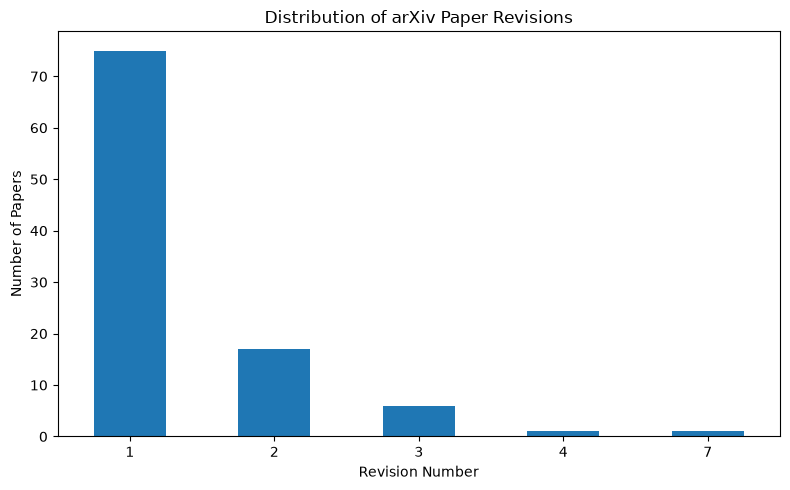

In [29]:
revision_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of arXiv Paper Revisions")
plt.xlabel("Revision Number")
plt.ylabel("Number of Papers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Revision findings

Most papers in the sample are still on their first version, with 75 out of 100 papers labeled as v1.

However, 25 papers have been revised at least once, including one paper that reached version 7. This suggests that the ingestion pipeline should be able to recognize newer versions of an existing paper instead of treating every revision as a completely new document.

### Content Analysis of Paper Abstracts

Use the abstracts from all 100 papers to identify important research terms, common themes, and similarities between papers.

In [30]:
content_df = df[
    ["arxiv_id", "title", "abstract", "categories"]
].copy()

content_df.head()

,arxiv_id,title,abstract,categories
0,2602.00937v3,CLAMP: Contrastive Learning for 3D Multi-View ...,Leveraging pre-trained 2D image representation...,"cs.RO, cs.AI, cs.CV, cs.LG"
1,2602.00933v3,MCP-Atlas: A Large-Scale Benchmark for Tool-Us...,The Model Context Protocol (MCP) is emerging a...,"cs.SE, cs.AI"
2,2602.00931v2,Continuous-Utility Direct Preference Optimization,Large language model reasoning is often treate...,"cs.LG, cs.AI"
3,2602.00929v1,Learning Abstractions for Hierarchical Plannin...,Humans learn abstractions and use them to plan...,cs.AI
4,2602.00924v3,Supervised sparse auto-encoders for interpreta...,Sparse auto-encoders (SAEs) have re-emerged as...,cs.AI


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import pandas as pd

# Extra generic academic words that usually do not describe the actual topic
custom_stop_words = {
    "paper", "papers",
    "study", "studies",
    "method", "methods",
    "approach", "approaches",
    "result", "results",
    "propose", "proposed",
    "show", "shows",
    "using", "use", "used",
    "based"
}

# Built-in English stop words + our extra research words
stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    strip_accents="unicode"
)

# Analyze all 100 abstracts
tfidf_matrix = vectorizer.fit_transform(content_df["abstract"])

# Get the words and phrases TF-IDF kept
feature_names = vectorizer.get_feature_names_out()

# Average TF-IDF importance across all papers
average_scores = tfidf_matrix.mean(axis=0).A1

# Count how many papers contain each term
document_counts = (tfidf_matrix > 0).sum(axis=0).A1

# Put the results into a clean table
top_terms_df = (
    pd.DataFrame({
        "term": feature_names,
        "avg_tfidf": average_scores,
        "papers_containing_term": document_counts
    })
    .sort_values("avg_tfidf", ascending=False)
    .head(30)
)
top_terms_df

,term,avg_tfidf,papers_containing_term
1232,models,0.032128,62
1224,model,0.030007,53
134,agents,0.027411,30
1065,language,0.024827,47
1894,task,0.024610,36
1899,tasks,0.023995,36
504,data,0.023675,34
124,agent,0.022638,28
1956,training,0.021045,34
1257,multi,0.020820,29


In [32]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

def clean_abstract(text):
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

content_df["clean_abstract"] = content_df["abstract"].apply(clean_abstract)

custom_stop_words = {
    "paper", "papers",
    "study", "studies",
    "method", "methods",
    "approach", "approaches",
    "result", "results",
    "propose", "proposed",
    "show", "shows",
    "using", "use", "used",
    "based"
}

stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

phrase_vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    ngram_range=(2, 3),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    strip_accents="unicode"
)

phrase_matrix = phrase_vectorizer.fit_transform(
    content_df["clean_abstract"]
)

phrase_names = phrase_vectorizer.get_feature_names_out()
phrase_scores = phrase_matrix.mean(axis=0).A1
phrase_doc_counts = (phrase_matrix > 0).sum(axis=0).A1

top_phrases_df = (
    pd.DataFrame({
        "phrase": phrase_names,
        "avg_tfidf": phrase_scores,
        "papers_containing_phrase": phrase_doc_counts
    })
    .sort_values("avg_tfidf", ascending=False)
    .head(30)
)

top_phrases_df

,phrase,avg_tfidf,papers_containing_phrase
159,large language,0.046636,31
151,language models,0.045985,27
161,large language models,0.035954,19
149,language model,0.034224,17
23,ai agents,0.028991,6
256,real world,0.026977,13
173,llm agents,0.025409,11
160,large language model,0.024313,12
150,language model llm,0.022145,11
193,model llm,0.022145,11


In [33]:
import re
import pandas as pd

def clean_abstract(text):
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

content_df["clean_abstract"] = content_df["abstract"].apply(clean_abstract)

themes = {
    "LLMs / Language Models": [
        "large language model",
        "large language models",
        "language model",
        "language models",
        "llm",
        "llms"
    ],
    "AI Agents": [
        "ai agent",
        "ai agents",
        "llm agent",
        "llm agents",
        "agentic"
    ],
    "Multi-Agent Systems": [
        "multi agent",
        "multi-agent",
        "multiagent"
    ],
    "World Models": [
        "world model",
        "world models"
    ],
    "Fine-Tuning": [
        "fine tuning",
        "fine-tuning"
    ],
    "Synthetic Data": [
        "synthetic data"
    ],
    "Natural Language": [
        "natural language"
    ],
    "Zero-Shot Learning": [
        "zero shot",
        "zero-shot"
    ]
}

theme_counts = []

for theme, keywords in themes.items():
    count = content_df["clean_abstract"].apply(
        lambda text: any(keyword in text for keyword in keywords)
    ).sum()

    theme_counts.append({
        "theme": theme,
        "papers": count
    })

theme_df = (
    pd.DataFrame(theme_counts)
    .sort_values("papers", ascending=False)
)

theme_df

,theme,papers
0,LLMs / Language Models,51
1,AI Agents,16
4,Fine-Tuning,8
2,Multi-Agent Systems,7
7,Zero-Shot Learning,6
3,World Models,5
6,Natural Language,5
5,Synthetic Data,4


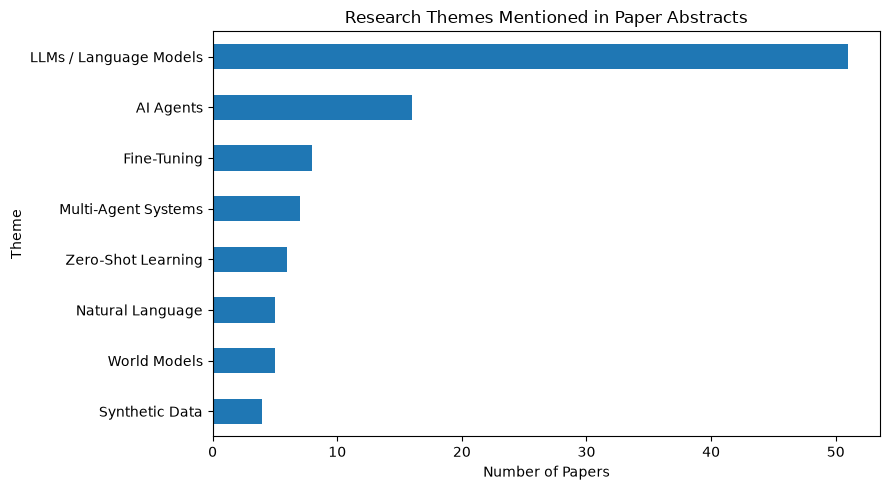

In [34]:
theme_df.sort_values("papers").plot(
    x="theme",
    y="papers",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

plt.title("Research Themes Mentioned in Paper Abstracts")
plt.xlabel("Number of Papers")
plt.ylabel("Theme")
plt.tight_layout()
plt.show()

### Research theme findings

LLM and language-model terminology appears most frequently in the abstract sample, occurring in 51 of the 100 papers. AI-agent terminology appears in 16 papers, while smaller groups mention fine-tuning, multi-agent systems, zero-shot learning, world models, natural language, and synthetic data.

These theme counts are based on keyword matching and can overlap because one paper may mention multiple themes. They should therefore be interpreted as theme prevalence in the abstracts rather than mutually exclusive topic categories.

### Task 2.3 Summary

The 100-paper sample covers 27 category labels. The most common co-categories are cs.LG with 31 papers, cs.CL with 22, and cs.CV with 12, showing that the corpus spans several AI-related areas.

The 25 sampled PDFs have a median length of 23 pages and an average of 27.72 pages, with one 157-page outlier. This variation may affect the amount of text, chunks, embeddings, and storage needed later in the RAG pipeline.

In the abstract analysis, LLM/language-model terminology appears in 51 papers and AI-agent terminology in 16 papers. These theme counts can overlap, so they show theme prevalence rather than exact topic classification.

Overall, the dataset has useful topic variety and document-size variation

## 2.4 PDF Text-Extractability 

In [35]:
import fitz  # PyMuPDF

extractability_results = []

for filename in pdf_files:
    file_path = os.path.join(pdf_dir, filename)
    doc = fitz.open(file_path)

    total_chars = 0
    for page in doc:
        total_chars += len(page.get_text())

    num_pages = len(doc)
    avg_chars_per_page = total_chars / num_pages if num_pages > 0 else 0

    status = "Needs OCR" if avg_chars_per_page < 50 else "OK"

    extractability_results.append({
        "filename": filename,
        "num_pages": num_pages,
        "chars_extracted": total_chars,
        "avg_chars_per_page": round(avg_chars_per_page, 1),
        "status": status
    })

    doc.close()

In [36]:
extract_df = pd.DataFrame(extractability_results)
extract_df

,filename,num_pages,chars_extracted,avg_chars_per_page,status
0,2602.00937v3.pdf,16,68381,4273.8,OK
1,2602.00933v3.pdf,25,78750,3150.0,OK
2,2602.00931v2.pdf,32,102987,3218.3,OK
3,2603.00829v2.pdf,36,123347,3426.3,OK
4,2603.00824v2.pdf,35,104490,2985.4,OK
5,2603.00823v2.pdf,18,69715,3873.1,OK
6,2604.00324v1.pdf,157,317950,2025.2,OK
7,2604.00319v1.pdf,36,83584,2321.8,OK
8,2604.00314v1.pdf,7,36939,5277.0,OK
9,2605.00292v2.pdf,20,78127,3906.3,OK


In [37]:
ok_count = (extract_df["status"] == "OK").sum()
ocr_count = (extract_df["status"] == "Needs OCR").sum()

print("PDFs with extractable text:", ok_count)
print("PDFs likely needing OCR:", ocr_count)

PDFs with extractable text: 25
PDFs likely needing OCR: 0


# 2.4 Findings

- All 25 sampled PDFs yielded extractable text; none fell below the average-character OCR heuristic.
- This is a sample-level text-presence check. It does not establish layout/table fidelity or rule out image-only pages inside an otherwise text-based paper.


## 2.5 — EDA Summary & Implications for Pipeline/Chunking Design

### Summary of Findings

**Metadata (2.2):** The sample contains 100 cs.AI papers across 8 metadata fields (arxiv_id, title, 
authors, abstract, categories, published, updated, pdf_url), all fully populated with no missing or 
blank values. Papers span 27 unique category labels, with multiple categories per paper stored as 
comma-separated text. 

**Distribution (2.3):** 

The sample is mostly comprised of cs.AI category papers which creates it the majority category. The sample includes around 11 papers for each month in 2026 and 12 papers in the month of September creating a reliable spread.

LLM and language-model terminology appears most frequently in the abstract sample, occurring in 51 of the 100 papers. AI-agent terminology appears in 16 papers, while smaller groups mention fine-tuning, multi-agent systems, zero-shot learning, world models, natural language, and synthetic data.

Most of the 25 sampled papers are between about 7 and 40 pages, with most of them around the 10-25 page range.
However, one paper has 157 pages, creating a right-skewed distribution. 

**Text-Extractability & Data Quality (2.4):** 
All 25 sampled PDFs produced extractable text via PyMuPDF and none fell below the notebook’s average-character OCR heuristic. This checks text presence, not layout/table fidelity or every page’s OCR needs. No duplicate IDs or missing/blank metadata fields were found in the committed sample.

### Implications for Pipeline & Chunking Design

- **No OCR needed (yet):** Since all sampled PDFs yielded extractable text, Task 4's pipeline can focus purely on direct text extraction + cleaning for now, without building OCR handling as a requirement. We should re-check this assumption as we pull larger/more varied samples, since OCR needs can vary by publisher or paper age.

- **Category field is usable for retrieval filtering:** The 'categories' field is clean and consistently populated, so it can support metadata-based filtering during retrieval 

- **Chunk size:** Given a typical paper length of 7–39 pages (median 23), a standard chunking approach (e.g. splitting by section/paragraph, targeting 500–1000 tokens per chunk) should work well. 
The one 157-page outlier is worth flagging for Task 4 — it may need special handling (e.g. more aggressive chunking, or confirming it's genuinely a single paper and not a merged PDF) so it doesn't produce an unusually large number of chunks relative to the rest of the dataset.